# Check Boosting Models

Evaluating Boosting Models...

                Model       MAE       MSE  R2 Score  CV R2 Mean  CV R2 Std
2            XGBoost  0.073359  0.007769  0.904935    0.874201   0.009033
4           CatBoost  0.074529  0.008055  0.901439    0.866608   0.012390
3           LightGBM  0.076976  0.008901  0.891087    0.860895   0.007247
0  Gradient Boosting  0.112509  0.021665  0.734914    0.723821   0.031894
1           AdaBoost  0.189982  0.045430  0.444125    0.466274   0.032230


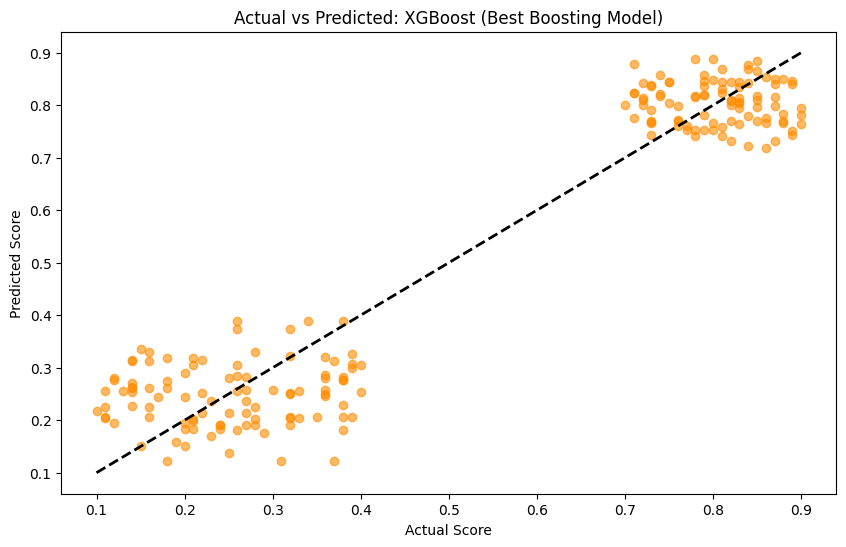

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modern Boosting Libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Load data and remove duplicates
df = pd.read_csv('/content/heart.csv')
df_unique = df.drop_duplicates()

X = df_unique.drop('target', axis=1)
y = df_unique['target']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the full suite of boosting models
boosting_models = {
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

results = []

print("Evaluating Boosting Models...")
for name, model in boosting_models.items():
    # Fit and Predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate standard metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Cross Validation (Stability check)
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "R2 Score": r2,
        "CV R2 Mean": cv_scores.mean(),
        "CV R2 Std": cv_scores.std()
    })

# Compare and Sort Results
results_df = pd.DataFrame(results).sort_values(by='CV R2 Mean', ascending=False)
print("\n", results_df)

# Plotting the leader
best_model_name = results_df.iloc[0]['Model']
best_model = boosting_models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title(f'Actual vs Predicted: {best_model_name} (Best Boosting Model)')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.show()

# Check for Overfitting

Computing learning curve for Gradient Boosting...
Computing learning curve for AdaBoost...
Computing learning curve for XGBoost...
Computing learning curve for LightGBM...
Computing learning curve for CatBoost...


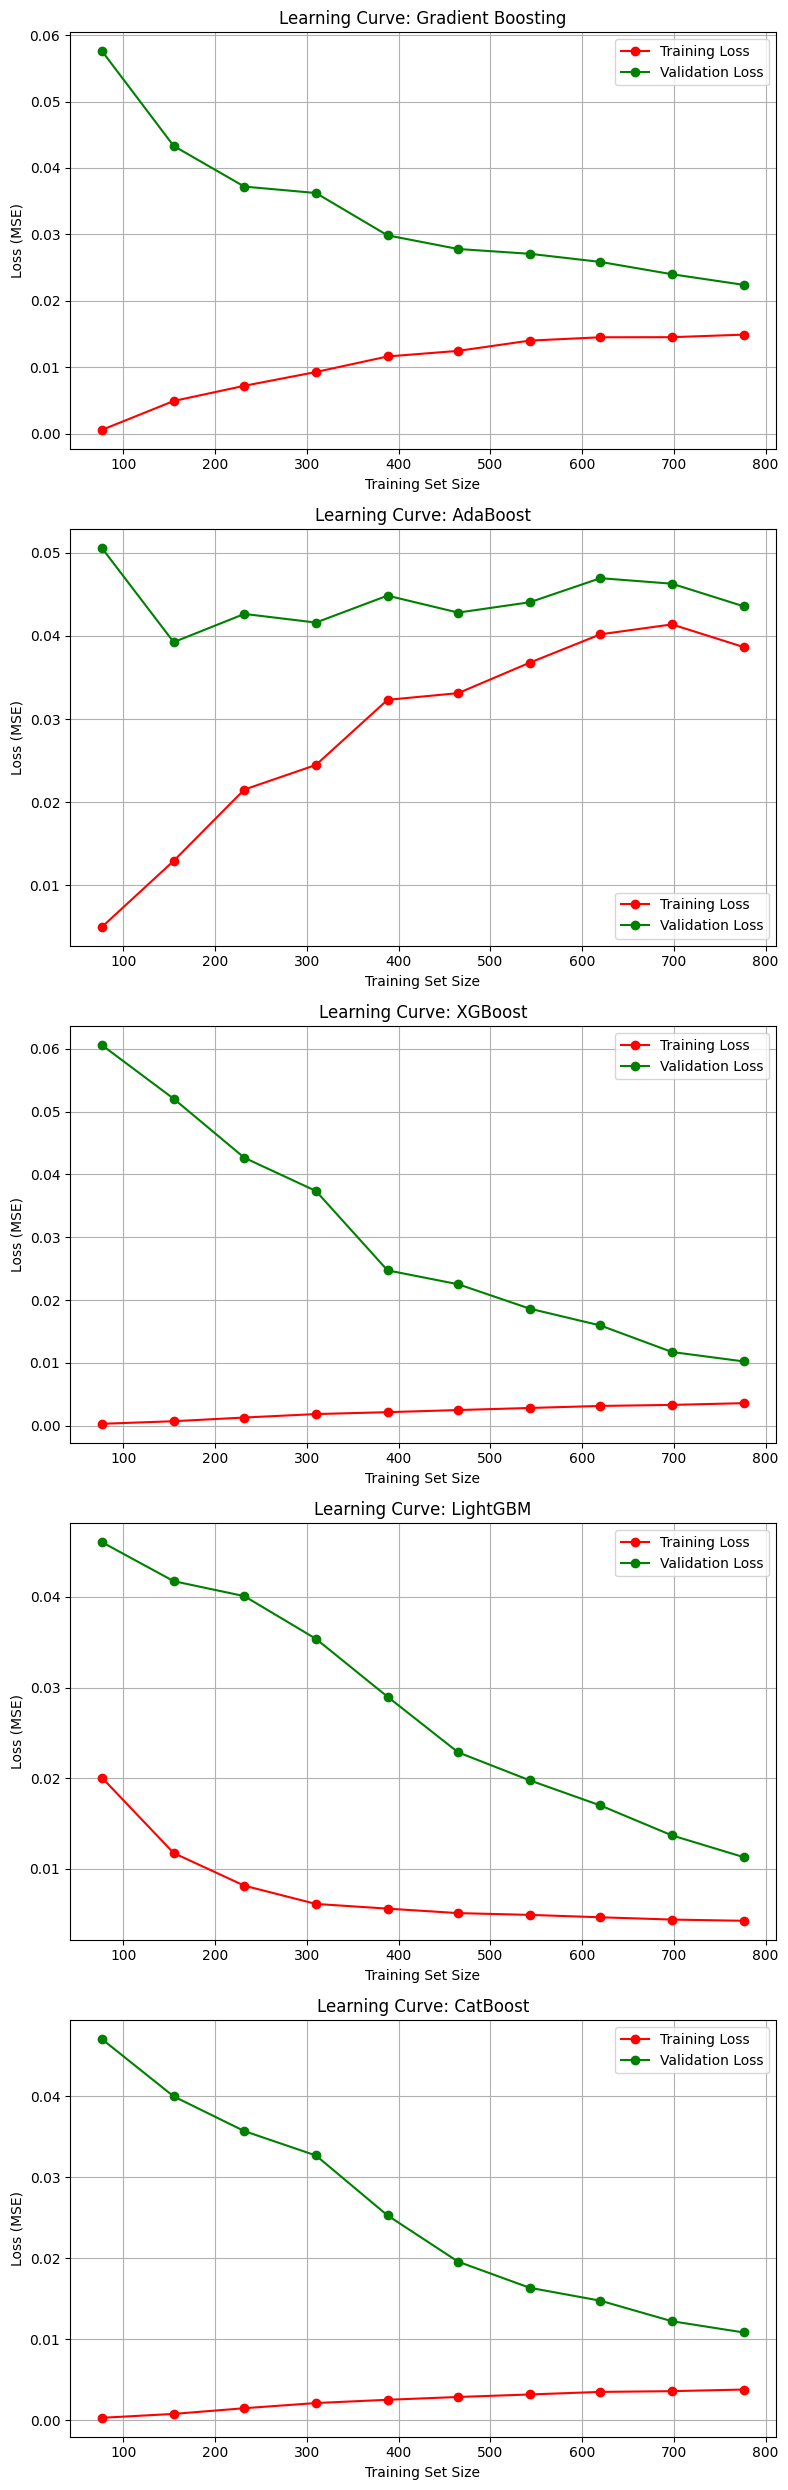

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Load data
df = pd.read_csv('/content/heart.csv')
df_unique = df.drop_duplicates()
X = df_unique.drop('target', axis=1)
y = df_unique['target']

# Define models
models = {
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

def plot_learning_curves(models, X, y):
    n_models = len(models)
    fig, axes = plt.subplots(nrows=n_models, ncols=1, figsize=(8, 5 * n_models))

    if n_models == 1: axes = [axes]

    for ax, (name, model) in zip(axes, models.items()):
        print(f"Computing learning curve for {name}...")

        # Calculate learning curve data
        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=5, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10),
            scoring='neg_mean_squared_error'
        )

        # Convert Negative MSE to positive Loss
        train_loss = -np.mean(train_scores, axis=1)
        test_loss = -np.mean(test_scores, axis=1)

        # Plotting
        ax.plot(train_sizes, train_loss, 'o-', color="r", label="Training Loss")
        ax.plot(train_sizes, test_loss, 'o-', color="g", label="Validation Loss")
        ax.set_title(f"Learning Curve: {name}")
        ax.set_xlabel("Training Set Size")
        ax.set_ylabel("Loss (MSE)")
        ax.legend(loc="best")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

plot_learning_curves(models, X, y)

# Hyperparameter tuning

Tuning CatBoost...

CatBoost Results:
Best Params: {'learning_rate': 0.05, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 8, 'border_count': 50}
R2 Score: 0.9033
MSE: 0.0079


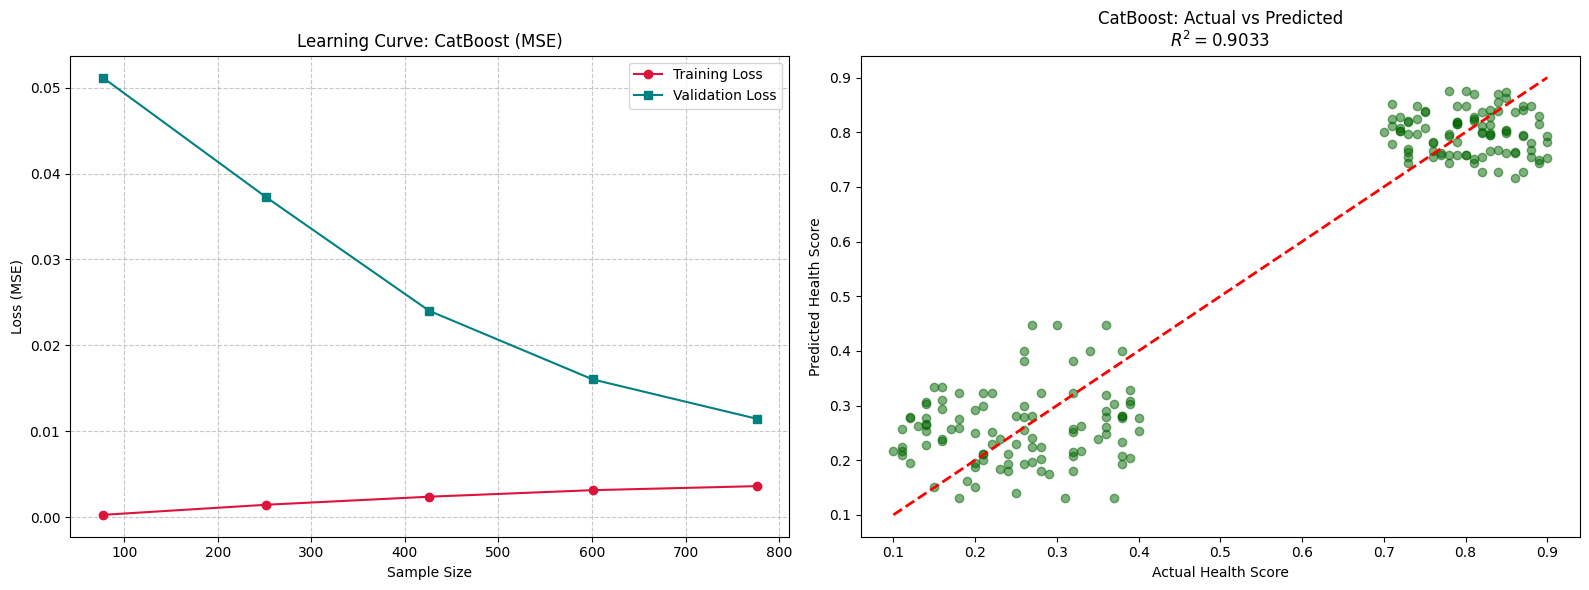

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
from catboost import CatBoostRegressor

# 1. Load and Advanced Feature Engineering
df = pd.read_csv('/content/heart.csv').drop_duplicates()
X = df.drop('target', axis=1).copy()
y = df['target']

# Engineered Features (from your GBR example)
X['log_chol'] = np.log1p(X['chol'])
X['log_oldpeak'] = np.log1p(X['oldpeak'])
X['hr_reserve'] = (220 - X['age']) - X['thalach']

# One-Hot Encode Categorical Features
categorical_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']
X_final = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

# 2. Define Enhanced Parameter Grids
cat_param_grid = {
    'iterations': [200, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5, 7],
    'border_count': [32, 50, 100]
}

# 3. Hyperparameter Tuning
print("Tuning CatBoost...")
cat_search = RandomizedSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    cat_param_grid, n_iter=15, cv=3, scoring='r2', n_jobs=-1, random_state=42
)
cat_search.fit(X_train, y_train)

best_models = {
    "CatBoost": cat_search.best_estimator_
}

# 4. Evaluation and Visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (name, model) in enumerate(best_models.items()):
    # Predictions
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print(f"\n{name} Results:")
    print(f"Best Params: {cat_search.best_params_}")
    print(f"R2 Score: {r2:.4f}")
    print(f"MSE: {mse:.4f}")

    # Plot 1: Learning Curve (MSE Loss)
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_final, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 5),
        scoring='neg_mean_squared_error', n_jobs=-1
    )
    train_loss = -np.mean(train_scores, axis=1)
    val_loss = -np.mean(test_scores, axis=1)

    axes[0].plot(train_sizes, train_loss, 'o-', color='crimson', label='Training Loss')
    axes[0].plot(train_sizes, val_loss, 's-', color='teal', label='Validation Loss')
    axes[0].set_title(f'Learning Curve: {name} (MSE)')
    axes[0].set_xlabel('Sample Size')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Actual vs Predicted
    axes[1].scatter(y_test, y_pred, alpha=0.5, color='indigo' if name == 'XGBoost' else 'darkgreen')
    axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
    axes[1].set_title(f'{name}: Actual vs Predicted\n$R^2 = {r2:.4f}$')
    axes[1].set_xlabel('Actual Health Score')
    axes[1].set_ylabel('Predicted Health Score')

plt.tight_layout()
plt.show()

# Saving Models

In [4]:
import joblib
import os

# Create a directory to store the models
os.makedirs('models', exist_ok=True)

# Save CatBoost
cat_filename = 'models/best_catboost_model_enhanced.cbm'
best_models['CatBoost'].save_model(cat_filename, format="cbm")
print(f"CatBoost model saved to: {cat_filename}")

# Save the feature names
feature_columns = X_final.columns.tolist()
joblib.dump(feature_columns, 'models/feature_columns.joblib')
print("Feature column names saved successfully.")

CatBoost model saved to: models/best_catboost_model_enhanced.cbm
Feature column names saved successfully.


# Testing

In [5]:
import pandas as pd
import numpy as np
import joblib
from catboost import CatBoostRegressor

# 1. Setup - Define your custom patient data
custom_patient = {
    'age': 62,
    'sex': 1,
    'cp': 1,
    'trestbps': 140,
    'chol': 260,
    'fbs': 0,
    'restecg': 0,
    'thalach': 120,
    'exang': 1,
    'oldpeak': 1.8,
    'slope': 1,
    'ca': 2,
    'thal': 3
}

# 2. Convert to DataFrame
input_df = pd.DataFrame([custom_patient])

# 3. Apply Advanced Feature Engineering (Same as training)
input_df['log_chol'] = np.log1p(input_df['chol'])
input_df['log_oldpeak'] = np.log1p(input_df['oldpeak'])
input_df['hr_reserve'] = (220 - input_df['age']) - input_df['thalach']

# 4. One-Hot Encoding and Alignment
try:
    model_columns = joblib.load('models/feature_columns.joblib')

    # Create dummies for the custom input
    categorical_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']
    input_final = pd.get_dummies(input_df, columns=categorical_cols)

    # Add any missing columns that were in training but not in this specific input
    for col in model_columns:
        if col not in input_final.columns:
            input_final[col] = 0

    # Ensure columns are in the EXACT same order as training
    input_final = input_final[model_columns]

except FileNotFoundError:
    print("Error: feature_columns.joblib not found. Ensure you saved it during training.")

# 5. Load Models and Predict
print("--- Prediction Results ---")

# Test CatBoost
try:
    cat_model = CatBoostRegressor()
    cat_model.load_model('models/best_catboost_model_enhanced.cbm')
    cat_pred = cat_model.predict(input_final)[0]
    print(f"CatBoost Predicted Risk Score: {1 - cat_pred:.4f}")
except Exception as e:
    print(f"CatBoost Loading/Prediction Error: {e}")

--- Prediction Results ---
CatBoost Predicted Risk Score: 0.7596
